[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part3-causal-inference/sec3.5_uplift_modeling.ipynb)

# Uplift Modeling for Targeting (MineThatData)

Companion notebook for **§3.5 Uplift Modeling for Targeting** of *Marketing
Science in Python*. §3.4 was about **measurement** — estimating each customer's
treatment effect (CATE). This notebook is about **action**: turning those scores
into targeting decisions and grading how well the ranking works.

**We deliberately reuse §3.4's semi-synthetic MineThatData example.** We take the
**real customer features** and the **real randomized assignment** (Men's e-mail
vs. no e-mail) from Kevin Hillstrom's MineThatData experiment, but **simulate**
the outcomes from a treatment effect `true_tau(x)` we define. Because the true
effect is known, every step of the targeting workflow can be graded against the
truth — which is exactly what a noisy real dataset will not let us do. This is a
**teaching device, not a claim that we can beat a randomized experiment's average
effect**, and not a production success story.

Using the same data and the same `RANDOM_STATE = 42` as §3.4 makes the two
chapters a single line: **§3.4 estimates who responds incrementally → §3.5
decides whom to target.**

**Workflow:**
1. Recreate §3.4's semi-synthetic dataset (same seed) and re-fit the same five
   meta-learners; carry forward the **representative** CATE score.
2. Rank customers, bucket into deciles, and read observed (and true) uplift per
   decile on the randomized holdout.
3. Grade the ranking with an uplift curve and a Qini curve against random.
4. Convert scores into **net value** after treatment cost to decide whom to treat.

### Setup

Required packages: `econml`, `lightgbm`, `scikit-uplift`. They are pinned in this
project's `environment.yml` (conda env `marketing-science`) and
`notebooks/part3-causal-inference/requirements.txt`. The data and figure paths
are resolved through the `msbook` helper package (installed with
`pip install -e .` from the repo root). **Colab readers** can install the
modelling packages by uncommenting:

```python
!pip install -q econml lightgbm scikit-uplift
```

In [1]:
import importlib.metadata
import sys

print(f"Python: {sys.version}")
print(f"econml: {importlib.metadata.version('econml')}")
print(f"lightgbm: {importlib.metadata.version('lightgbm')}")
print(f"scikit-uplift: {importlib.metadata.version('scikit-uplift')}")

# --- Compatibility patch: econml 0.16 uses deprecated `force_all_finite` ---
# scikit-learn >=1.8 renamed check_array(force_all_finite=...) to
# check_array(ensure_all_finite=...). Patch until econml releases a fix.
import sklearn.utils.validation as _skval
_original_check_array = _skval.check_array

def _patched_check_array(*args, **kwargs):
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return _original_check_array(*args, **kwargs)

_skval.check_array = _patched_check_array
import sklearn.utils
sklearn.utils.check_array = _patched_check_array
# --- End compatibility patch ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.special import expit

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from econml.metalearners import SLearner, TLearner, XLearner
from econml.dr import DRLearner
from econml.dml import CausalForestDML

# Apply patch to all econml modules that imported check_array
for _mod_name in list(sys.modules.keys()):
    if _mod_name.startswith('econml') and hasattr(sys.modules[_mod_name], 'check_array'):
        sys.modules[_mod_name].check_array = _patched_check_array

# Suppress noisy logs and known-harmless warnings so the notebook output reads cleanly.
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=DataConversionWarning)
warnings.filterwarnings(action='ignore', category=UserWarning,
                        message='X does not have valid feature names')

try:
    display
except NameError:
    display = print

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Python: 3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 08:43:59) [Clang 18.1.8 ]
econml: 0.16.0
lightgbm: 4.6.0
scikit-uplift: 0.5.1


In [2]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo's _quarto.yml, so it needs the repo
# tree present, which the clone provides.)
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401

# Resolved by msbook so figures land in images/part3/sec3.5/ from any cwd.
from msbook.paths import chapter_images

_FIG_DIR = chapter_images(part="3", chapter="sec3.5")


def savefig(fig, name, **kw):
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(_FIG_DIR / name, **kw)

## 1. Recreate the §3.4 Semi-Synthetic Dataset

We rebuild the **exact** dataset from §3.4: the real MineThatData customer
features and randomized Men's-e-mail-vs-control assignment, with semi-synthetic
outcomes drawn from a known `true_tau(x)`. The same `RANDOM_STATE = 42` and the
same generation code mean the data here is identical to §3.4 — so the CATE scores
we estimate below are the same ones §3.4 reported, now carried forward into
targeting.

| Column | Meaning |
|--------|---------|
| `recency` | months since last purchase (1–12) |
| `history` | dollars spent in the past year |
| `mens` / `womens` | bought men's / women's merchandise in the past year |
| `zip_code` | Urban / Suburban / Rural |
| `newbie` | new customer in the past year |
| `channel` | Phone / Web / Multichannel |
| `segment` | randomized arm (Mens / Womens / No E-Mail) |

In [3]:
from msbook.data import load_minethatdata

df = load_minethatdata()
print(f"Full dataset: {len(df):,} customers across {df['segment'].nunique()} arms")

# Keep the binary contrast: Men's e-mail (treatment) vs. No e-mail (control).
df = df[df['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()
df['treatment'] = (df['segment'] == 'Mens E-Mail').astype(int)

print(f"After filtering to Men's e-mail vs. control: {len(df):,} customers")
print(f"Treatment rate (randomized): {df['treatment'].mean():.1%}")

Full dataset: 64,000 customers across 3 arms
After filtering to Men's e-mail vs. control: 42,613 customers
Treatment rate (randomized): 50.0%


In [4]:
# Customer features: recency, history, mens, newbie + one-hot channel / zip_code.
feature_cols = ['recency', 'history', 'mens', 'newbie']
X = pd.get_dummies(
    df[feature_cols + ['channel', 'zip_code']],
    columns=['channel', 'zip_code'],
    drop_first=True,
).astype(float)

T = df['treatment'].to_numpy().astype(int)

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Columns: {list(X.columns)}")

Feature matrix: 42,613 rows x 8 columns
Columns: ['recency', 'history', 'mens', 'newbie', 'channel_Phone', 'channel_Web', 'zip_code_Surburban', 'zip_code_Urban']


### Semi-synthetic potential outcomes

Same construction as §3.4. On the probability scale we build a baseline `p0`
(what a customer does *without* the e-mail) and a true effect `true_tau(x)` that
is larger for men's-merchandise buyers, recently active customers, and
multichannel shoppers, with a sweet spot in the middle of the purchase-history
range. We draw both potential outcomes and reveal only the one matching each
customer's actual arm.

In [5]:
# Standardized drivers
rec = df['recency'].to_numpy(dtype=float)
loghist = np.log(df['history'].to_numpy(dtype=float))
loghist_z = (loghist - loghist.mean()) / loghist.std()
mens = df['mens'].to_numpy(dtype=float)
newbie = df['newbie'].to_numpy(dtype=float)
multichannel = (df['channel'] == 'Multichannel').to_numpy(dtype=float)
urban = (df['zip_code'] == 'Urban').to_numpy(dtype=float)

# --- Baseline probability p0: what the customer would do with no e-mail ---
logit0 = (-2.2
          - 0.45 * (rec - rec.mean()) / rec.std()   # recent buyers convert more
          + 0.35 * loghist_z                          # bigger spenders convert more
          + 0.15 * mens
          - 0.25 * newbie
          + 0.10 * urban)
p0 = expit(logit0)

# --- True treatment effect true_tau(x), on the probability scale ---
recent_factor = expit(-(rec - 4.0) / 1.5)             # recently active respond more
hist_moderate = np.exp(-0.5 * (loghist_z / 1.0) ** 2)  # moderate-history sweet spot

true_tau = (0.005
            + 0.090 * mens            # men's e-mail moves men's buyers most
            + 0.050 * multichannel    # multichannel customers more responsive
            + 0.060 * recent_factor
            + 0.045 * hist_moderate)

# --- Treated probability and potential outcomes ---
p1 = np.clip(p0 + true_tau, 0.0, 1.0)
true_tau = p1 - p0                      # exact effect after clipping

y0 = rng.binomial(1, p0)
y1 = rng.binomial(1, p1)
y = np.where(T == 1, y1, y0).astype(int)   # observed outcome

df['true_tau'] = true_tau
df['y'] = y

print(f"Baseline rate  E[p0]       = {p0.mean():.3f}")
print(f"True ATE       E[true_tau] = {true_tau.mean():.4f}  ({true_tau.mean():.2%})")
print(f"True effect spread (SD)    = {true_tau.std():.4f}")
print(f"Observed conversion rate   = {y.mean():.3f}")

Baseline rate  E[p0]       = 0.114
True ATE       E[true_tau] = 0.1136  (11.36%)
True effect spread (SD)    = 0.0538
Observed conversion rate   = 0.169


## 2. Re-fit the §3.4 Learner Set and Pick the Representative Score

Targeting starts from a single per-customer uplift score. To stay faithful to
§3.4 we re-fit the **same five meta-learners** — S-, T-, X-, DR-Learner and a
Causal Forest — on the same 70/30 split, then keep the **representative** learner:
the one whose estimated CATE correlates highest with the true effect on the
held-out evaluation set.

> **This selection uses the truth only because the example is semi-synthetic.**
> In a real project `true_tau` is never observed, so you cannot rank learners by
> recovery. There you choose a score by **randomized-holdout performance** (the
> uplift / Qini curves below), **ranking stability across learners**, **mean-effect
> plausibility** against the experiment, and **business validation** — never by
> peeking at a truth you do not have.

We keep this section to **one compact recovery table**; the heterogeneity figures
live in §3.4. From here on, the chapter is about turning the chosen score into a
decision.

In [6]:
X_train, X_eval, T_train, T_eval, y_train, y_eval, tau_train, tau_eval = train_test_split(
    X.to_numpy(), T, y, true_tau,
    test_size=0.30, stratify=T, random_state=RANDOM_STATE,
)
print(f"Train: {len(X_train):,} rows   Eval: {len(X_eval):,} rows")

lgbm_reg_params = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
                       verbose=-1, random_state=RANDOM_STATE, n_jobs=-1)
lgbm_clf_params = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
                       verbose=-1, random_state=RANDOM_STATE, n_jobs=-1)

estimators = {
    'S-Learner': SLearner(overall_model=LGBMRegressor(**lgbm_reg_params)),
    'T-Learner': TLearner(models=[LGBMRegressor(**lgbm_reg_params),
                                   LGBMRegressor(**lgbm_reg_params)]),
    'X-Learner': XLearner(
        models=[LGBMRegressor(**lgbm_reg_params), LGBMRegressor(**lgbm_reg_params)],
        propensity_model=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    ),
    'DR-Learner': DRLearner(
        model_regression=LGBMClassifier(**lgbm_clf_params),
        model_propensity=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        model_final=LGBMRegressor(**lgbm_reg_params),
        discrete_outcome=True, cv=3, mc_iters=3,
    ),
    'CausalForestDML': CausalForestDML(
        model_y=LGBMClassifier(**lgbm_clf_params),
        model_t=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        discrete_treatment=True, discrete_outcome=True,
        n_estimators=200, random_state=RANDOM_STATE, cv=3, mc_iters=3,
    ),
}

results = {}
y_train_f = y_train.astype(float)
for name, est in estimators.items():
    t0 = time.time()
    if name in ('S-Learner', 'T-Learner', 'X-Learner'):
        est.fit(y_train_f, T_train, X=X_train)
    else:
        est.fit(Y=y_train_f, T=T_train, X=X_train)
    cate = est.effect(X_eval).flatten()
    results[name] = {'cate': cate, 'time': time.time() - t0}
    print(f"  {name:>16} — est. ATE {cate.mean():.4f}  ({results[name]['time']:.1f}s)")

print(f"\nTrue ATE on eval set: {tau_eval.mean():.4f}")

Train: 29,829 rows   Eval: 12,784 rows


         S-Learner — est. ATE 0.1075  (0.8s)


         T-Learner — est. ATE 0.1090  (1.3s)


         X-Learner — est. ATE 0.1089  (3.0s)


        DR-Learner — est. ATE 0.1091  (8.9s)


   CausalForestDML — est. ATE 0.1093  (9.1s)

True ATE on eval set: 0.1135


In [7]:
# Compact recovery table — the only method comparison in this chapter.
def recovery_row(name, cate):
    return {
        'Method': name,
        'Corr(est, true)': np.corrcoef(cate, tau_eval)[0, 1],
        'MAE': np.abs(cate - tau_eval).mean(),
        'RMSE': np.sqrt(((cate - tau_eval) ** 2).mean()),
        'Mean est. CATE': cate.mean(),
        'True ATE': tau_eval.mean(),
    }

recovery = pd.DataFrame([recovery_row(n, r['cate']) for n, r in results.items()])
recovery = recovery.sort_values('Corr(est, true)', ascending=False).reset_index(drop=True)
display(recovery.round(4))

,Method,"Corr(est, true)",MAE,RMSE,Mean est. CATE,True ATE
0,S-Learner,0.7706,0.0297,0.0413,0.1075,0.1135
1,X-Learner,0.6883,0.0379,0.0540,0.1089,0.1135
2,CausalForestDML,0.5958,0.0508,0.0662,0.1093,0.1135
3,T-Learner,0.5941,0.0503,0.0703,0.1090,0.1135
4,DR-Learner,0.5770,0.0493,0.0721,0.1091,0.1135


In [8]:
# Representative score: highest correlation with the true CATE (semi-synthetic only).
representative = recovery.iloc[0]['Method']
cate_rep = results[representative]['cate']
print(f"Representative learner (highest CATE recovery): {representative}")
print(f"Carrying its CATE forward as the uplift score for targeting.")

Representative learner (highest CATE recovery): S-Learner
Carrying its CATE forward as the uplift score for targeting.


## 3. From Scores to Targeting Decisions

Rank the held-out customers by the representative uplift score, cut into deciles
(decile 0 = highest score), and read the uplift inside each decile:

- **Predicted uplift** — the mean model score in the decile.
- **Observed uplift** — `mean(conversion | treated) − mean(conversion | control)`
  *within the decile*, computed on the randomized holdout. This is the number a
  real project would use to validate the ranking, because it needs no knowledge of
  the truth.
- **True uplift** — the mean of `true_tau` in the decile. Available only because
  the data is semi-synthetic; we show it as a **teaching check** on whether the
  observed and predicted columns are tracking reality.

In [9]:
decile_df = pd.DataFrame({
    'uplift': cate_rep,
    'treatment': T_eval,
    'conversion': y_eval,
    'true_tau': tau_eval,
})
# Scores can tie, so bucket on ranks (guarantees 10 equal deciles).
ranked = decile_df['uplift'].rank(method='first', ascending=False)
decile_df['decile'] = pd.qcut(ranked, q=10, labels=False)


def _decile_row(g):
    treated = g[g['treatment'] == 1]
    control = g[g['treatment'] == 0]
    t_cr = treated['conversion'].mean() if len(treated) else np.nan
    c_cr = control['conversion'].mean() if len(control) else np.nan
    return pd.Series({
        'n':                 len(g),
        'pred_uplift_%':     g['uplift'].mean() * 100,
        'observed_uplift_%': (t_cr - c_cr) * 100,
        'true_uplift_%':     g['true_tau'].mean() * 100,
    })


decile_summary = decile_df.groupby('decile', group_keys=False).apply(
    _decile_row, include_groups=False)
print('Decile 0 = highest predicted uplift, decile 9 = lowest.\n')
display(decile_summary.round(4))

Decile 0 = highest predicted uplift, decile 9 = lowest.



,n,pred_uplift_%,observed_uplift_%,true_uplift_%
decile,,,,
0,1279.0,22.7280,16.7647,18.0246
1,1278.0,17.1184,13.0510,15.8576
2,1278.0,14.7779,17.2438,14.8521
3,1279.0,13.0000,11.2570,14.1106
4,1278.0,11.3541,10.7629,13.3777
5,1278.0,9.6575,12.4681,11.6397
6,1279.0,7.6251,11.8207,8.6569
7,1278.0,5.7910,8.4083,6.2894
8,1278.0,4.2457,6.2326,5.5899


Predicted uplift is monotone by construction. The **top deciles carry
meaningfully higher uplift than the average** — the top decile is roughly 1.5–2×
the average effect, depending on whether you read the predicted, observed, or true
column — which is the concentration we are after, and the observed
(randomized-holdout) and true columns track it there. The middle and tail are
noisier: each decile holds only ~1,300 customers, so the observed difference in
means wobbles. Read the top of the ranking, not individual tail rows.

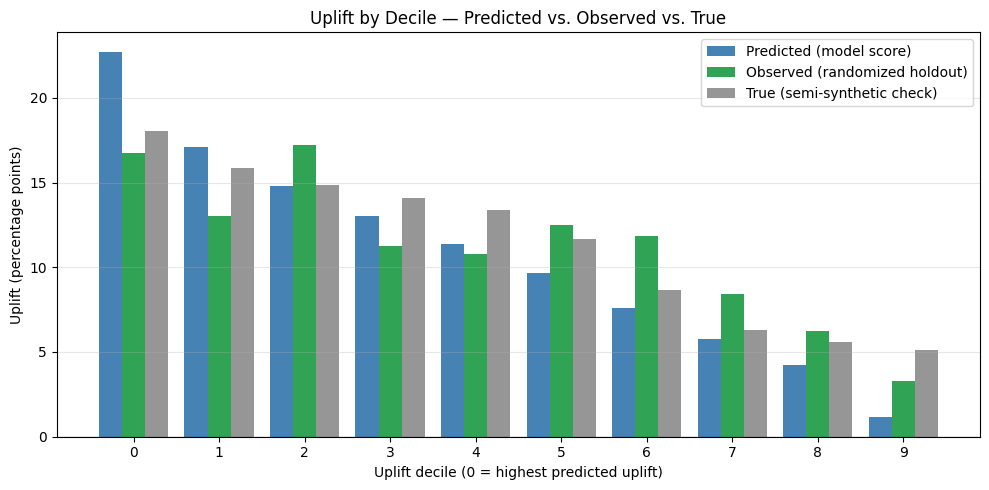

In [10]:
# Figure 1 — predicted vs. observed vs. true uplift by decile.
fig, ax = plt.subplots(figsize=(10, 5))
deciles = decile_summary.index.to_numpy()
w = 0.27
ax.bar(deciles - w, decile_summary['pred_uplift_%'], width=w,
       label='Predicted (model score)', color='steelblue')
ax.bar(deciles, decile_summary['observed_uplift_%'], width=w,
       label='Observed (randomized holdout)', color='#31a354')
ax.bar(deciles + w, decile_summary['true_uplift_%'], width=w,
       label='True (semi-synthetic check)', color='#969696')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Uplift decile (0 = highest predicted uplift)')
ax.set_ylabel('Uplift (percentage points)')
ax.set_title('Uplift by Decile — Predicted vs. Observed vs. True')
ax.set_xticks(deciles)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
savefig(fig, 'uplift_by_decile.png')
plt.show()

## 4. Grading the Ranking: Uplift Curve and Qini Curve

The uplift curve answers "if we treat the top-ranked customers, how many *extra*
conversions do we capture as we go deeper?" We build it from the deciles:
incremental conversions in a decile ≈ observed uplift × decile size, accumulated
best-first. A useful ranking bends above the random-targeting diagonal — the
straight line you get by treating customers in random order.

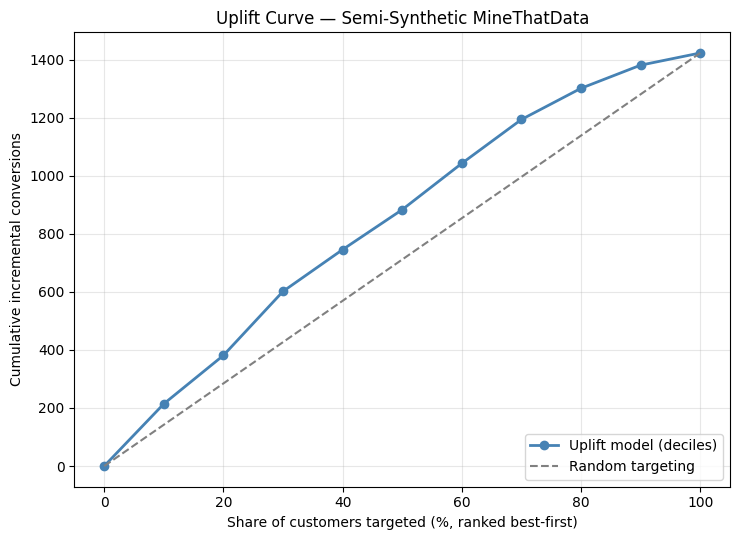

In [11]:
inc_per_decile = (decile_summary['observed_uplift_%'] / 100.0
                  * decile_summary['n']).to_numpy()
cum_customers = np.concatenate([[0], decile_summary['n'].cumsum().to_numpy()])
cum_incremental = np.concatenate([[0], inc_per_decile.cumsum()])
# Plot against share of customers targeted (more readable than raw counts).
cum_share = cum_customers / cum_customers[-1] * 100
total_incremental = cum_incremental[-1]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(cum_share, cum_incremental, marker='o', color='steelblue',
        linewidth=2, label='Uplift model (deciles)')
ax.plot([0, 100], [0, total_incremental], color='gray',
        linestyle='--', label='Random targeting')
ax.set_xlabel('Share of customers targeted (%, ranked best-first)')
ax.set_ylabel('Cumulative incremental conversions')
ax.set_title('Uplift Curve — Semi-Synthetic MineThatData')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
savefig(fig, 'uplift_curve.png')
plt.show()

Most of the incremental conversions are captured in the first few deciles, where
the curve rises steeply above the diagonal; the marginal gain then declines as we
move down the ranking, even though some middle deciles still show positive
observed uplift. That gap between the model curve and the diagonal is the value of
targeting by uplift instead of at random.

**The Qini curve** makes the same point at the per-customer level and is more
robust when the treated share drifts across the ranking. We report the area
summaries (AUUC and the Qini coefficient): both are positive, so the ranking beats
random. They are **relative** scores — positive means better than random, and they
are only comparable on the same holdout, not on an absolute 0-to-1 scale.

AUUC = 0.0404   Qini = 0.0695   (both > 0 ⇒ better than random)


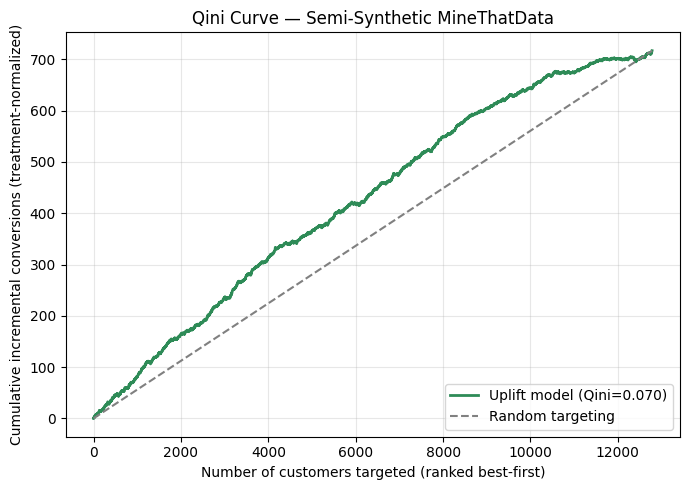

In [12]:
from sklift.metrics import qini_curve, qini_auc_score, uplift_auc_score

y_true_arr = y_eval.astype(int)
treat_arr = T_eval.astype(int)
auuc = uplift_auc_score(y_true_arr, cate_rep, treat_arr)
qini = qini_auc_score(y_true_arr, cate_rep, treat_arr)
print(f"AUUC = {auuc:.4f}   Qini = {qini:.4f}   (both > 0 ⇒ better than random)")

x_q, y_q = qini_curve(y_true_arr, cate_rep, treat_arr)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_q, y_q, color='seagreen', linewidth=2, label=f'Uplift model (Qini={qini:.3f})')
ax.plot([0, x_q[-1]], [0, y_q[-1]], color='gray', linestyle='--', label='Random targeting')
ax.set_xlabel('Number of customers targeted (ranked best-first)')
ax.set_ylabel('Cumulative incremental conversions (treatment-normalized)')
ax.set_title('Qini Curve — Semi-Synthetic MineThatData')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
savefig(fig, 'qini_curve.png')
plt.show()

## 5. Net Value: Whom to Actually Target

A score becomes a decision only once you attach economics. Suppose each
incremental conversion is worth **\$30** in expected margin, and contacting a
customer (the e-mail plus its offer) costs **\$3** — so a customer is worth
treating once their predicted uplift clears a **10%** break-even. The expected
net value of treating a customer with predicted uplift $\widehat\tau$ is

$$\text{net value} = \widehat\tau \times \text{value} - \text{treatment cost}.$$

Treat the deciles where net value is positive; skip the rest. *(These numbers are
illustrative — the point is the rule, not the constants.)*

In [13]:
value_per_conversion = 30.0   # $ margin per incremental conversion
treatment_cost = 3.0          # $ per contacted customer (e-mail + offer)

decile_summary['net_value_pred'] = (
    decile_summary['pred_uplift_%'] / 100.0 * value_per_conversion - treatment_cost)
decile_summary['net_value_obs'] = (
    decile_summary['observed_uplift_%'] / 100.0 * value_per_conversion - treatment_cost)
decile_summary['target?'] = np.where(
    decile_summary['net_value_pred'] > 0, 'YES', 'no')
display(decile_summary[['pred_uplift_%', 'observed_uplift_%',
                        'net_value_pred', 'net_value_obs', 'target?']].round(4))

,pred_uplift_%,observed_uplift_%,net_value_pred,net_value_obs,target?
decile,,,,,
0,22.7280,16.7647,3.8184,2.0294,YES
1,17.1184,13.0510,2.1355,0.9153,YES
2,14.7779,17.2438,1.4334,2.1732,YES
3,13.0000,11.2570,0.9000,0.3771,YES
4,11.3541,10.7629,0.4062,0.2289,YES
5,9.6575,12.4681,-0.1027,0.7404,no
6,7.6251,11.8207,-0.7125,0.5462,no
7,5.7910,8.4083,-1.2627,-0.4775,no
8,4.2457,6.2326,-1.7263,-1.1302,no


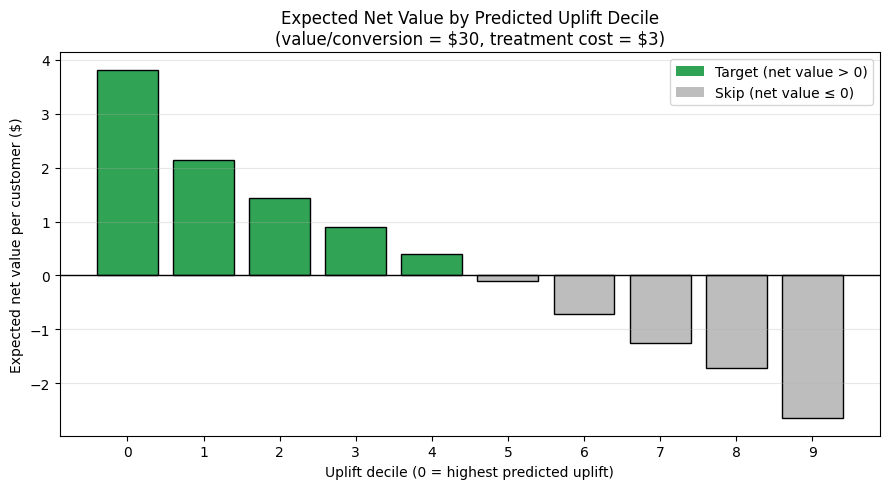

Under these economics, target the top 5 of 10 deciles.


In [14]:
# Figure 3 — expected net value per customer by decile (decision view).
fig, ax = plt.subplots(figsize=(9, 5))
deciles = decile_summary.index.to_numpy()
netvals = decile_summary['net_value_pred'].to_numpy()
colors = ['#31a354' if v > 0 else '#bdbdbd' for v in netvals]
ax.bar(deciles, netvals, color=colors, edgecolor='black')
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Uplift decile (0 = highest predicted uplift)')
ax.set_ylabel('Expected net value per customer ($)')
ax.set_title('Expected Net Value by Predicted Uplift Decile\n'
             f'(value/conversion = \\${value_per_conversion:.0f}, '
             f'treatment cost = \\${treatment_cost:.0f})')
ax.set_xticks(deciles)
ax.bar([0], [0], color='#31a354', label='Target (net value > 0)')
ax.bar([0], [0], color='#bdbdbd', label='Skip (net value ≤ 0)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
savefig(fig, 'net_value_by_decile.png')
plt.show()

n_target = int((decile_summary['net_value_pred'] > 0).sum())
print(f"Under these economics, target the top {n_target} of 10 deciles.")

Compare the `net_value_pred` and `net_value_obs` columns above: the decision
should hold up when you re-derive it from the **observed** randomized-holdout
uplift, not just from the model's predicted score. Where the two disagree near
the cutoff, the marginal deciles are exactly where you would run a fresh holdout
before committing budget — never act on predicted scores alone at the boundary.

## 6. Guardrails

- **Margin erosion.** The most common failure in targeting is paying out more in
  contact / discount cost than the incremental margin is worth. Always net the
  treatment cost out *before* deciding, as above.
- **Customer fatigue.** Even high-uplift customers disengage if contacted too
  often. Set frequency caps and watch whether uplift decays for recently
  contacted customers.
- **Sleeping dogs.** Real campaigns can have *negative*-uplift customers, where
  contact reduces conversion. This semi-synthetic example shows lower positive
  uplift in the tail rather than truly negative uplift, but the same net-value rule
  would steer you away from harmful segments.
- **Out-of-sample drift.** A ranking learned on past data degrades as behavior
  shifts. Validate the targeting policy with a fresh holdout experiment before
  trusting it at scale.

## Summary

- Carrying §3.4's representative CATE forward, the **top deciles concentrate the
  incremental conversions**, the uplift and Qini curves clear the random diagonal,
  and a net-value rule turns the score into a clear treat / skip decision.
- Because the example is **semi-synthetic**, we could check predicted against both
  observed and true uplift. Real projects only get the observed (randomized
  holdout) column — so build the habit of validating there.
- **Real uplift datasets can be noisy, and uplift models are not guaranteed to
  beat response models. Always evaluate any targeting score on randomized holdout
  data.**

Together with §3.4 the throughline is one sentence: **estimate who responds
incrementally, then decide whom to target.**